In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded =files.upload()

Saving Indian Airlines.csv to Indian Airlines.csv


In [4]:
df = pd.read_csv("Indian Airlines.csv")
df.head(10)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [6]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [8]:
df.shape

(300153, 12)

In [9]:
df.nunique()

,0
Unnamed: 0,300153
airline,6
flight,1561
source_city,6
departure_time,6
stops,3
arrival_time,6
destination_city,6
class,2
duration,476


In [12]:
df.columns                              # All column names


Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

Displays unique values of all categorical (object) columns.

In [15]:
for col in df:
    if df[col].dtype == 'object':
        print(df[col].unique())

['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
['zero' 'one' 'two_or_more']
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
['Economy' 'Business']


**Exploratory Data Analysis**

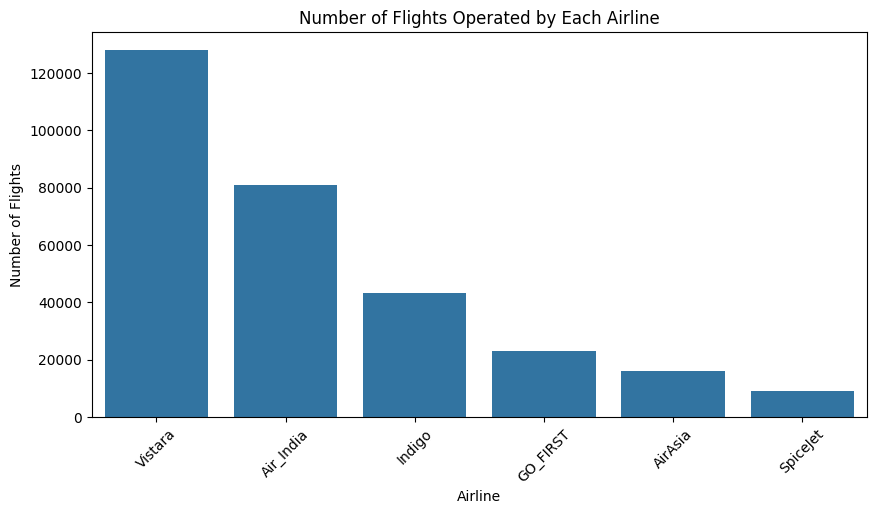

In [45]:
# What is the number of flights operated by each airline?
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='airline',
    order=df['airline'].value_counts().index
)

plt.title('Number of Flights Operated by Each Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')

plt.xticks(rotation=45)

plt.show()

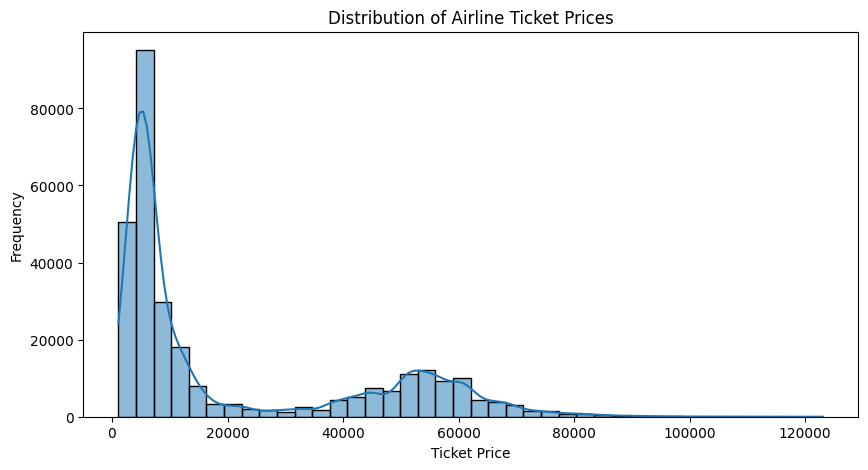

In [46]:
# What is the distribution of ticket prices?
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='price',
    bins=40,
    kde=True
)

plt.title('Distribution of Airline Ticket Prices')
plt.xlabel('Ticket Price')
plt.ylabel('Frequency')

plt.show()


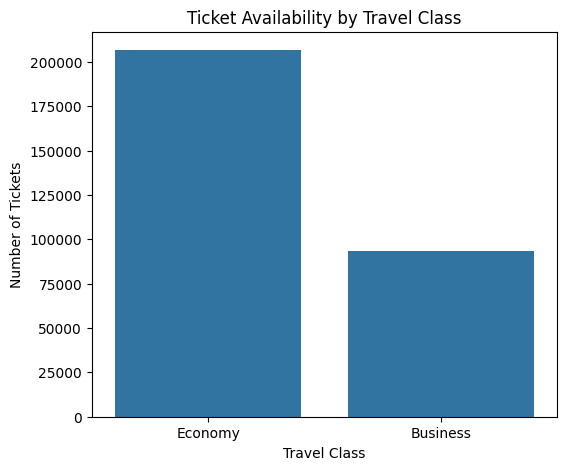

In [47]:
# What is the availability of Economy and Business class tickets?
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='class'
)

plt.title('Ticket Availability by Travel Class')
plt.xlabel('Travel Class')
plt.ylabel('Number of Tickets')

plt.show()

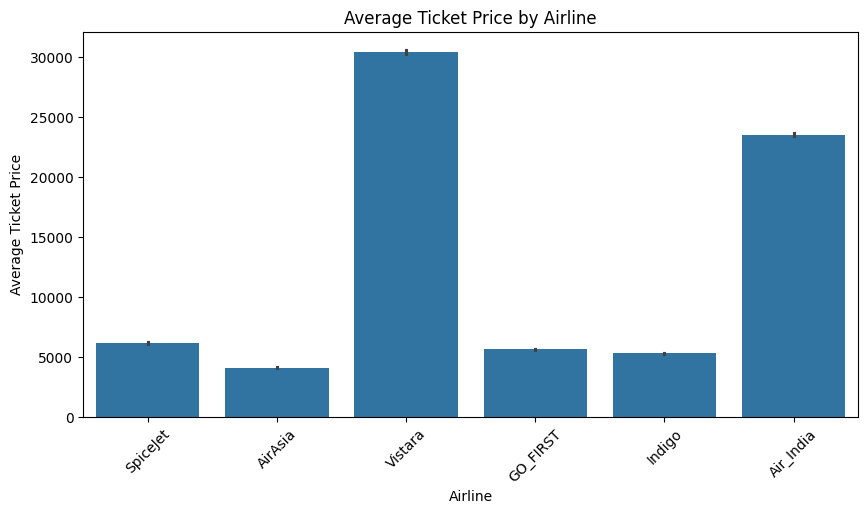

In [33]:
# How do average ticket prices vary across different airlines?
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='airline',
    y='price',
    estimator='mean'
)

plt.title('Average Ticket Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Ticket Price')

plt.xticks(rotation=45)

plt.show()

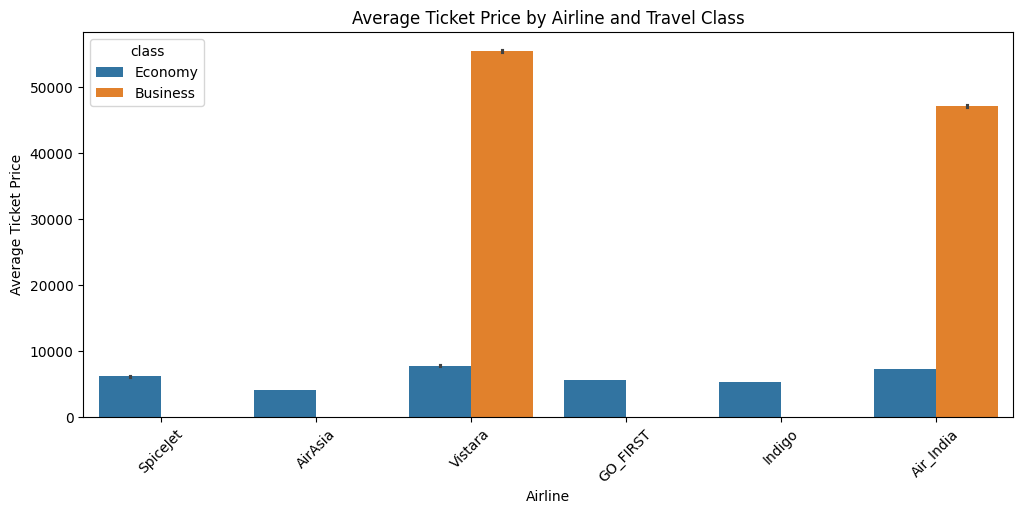

In [34]:
# How do ticket prices vary across airlines and travel classes?
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x='airline',
    y='price',
    hue='class'
)

plt.title('Average Ticket Price by Airline and Travel Class')
plt.xlabel('Airline')
plt.ylabel('Average Ticket Price')

plt.xticks(rotation=45)

plt.show()

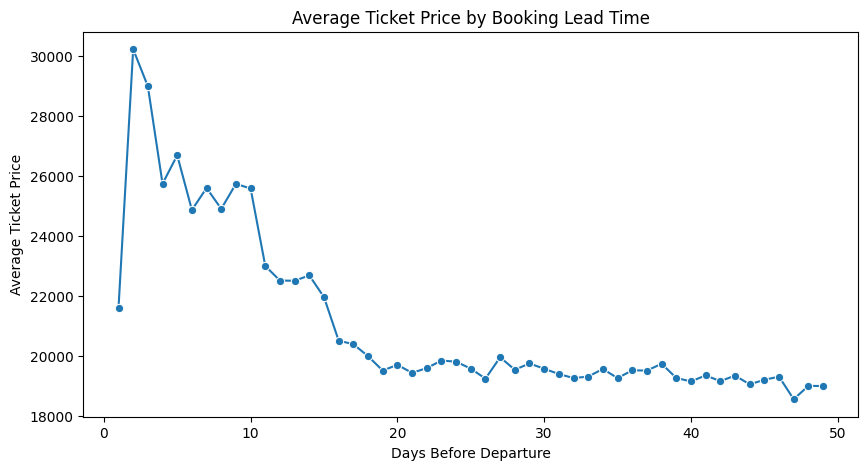

In [48]:
# How does booking lead time affect ticket prices?
plt.figure(figsize=(10,5))

booking_price = (
    df.groupby('days_left')['price']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=booking_price,
    x='days_left',
    y='price',
    marker='o'
)

plt.title('Average Ticket Price by Booking Lead Time')
plt.xlabel('Days Before Departure')
plt.ylabel('Average Ticket Price')

plt.show()

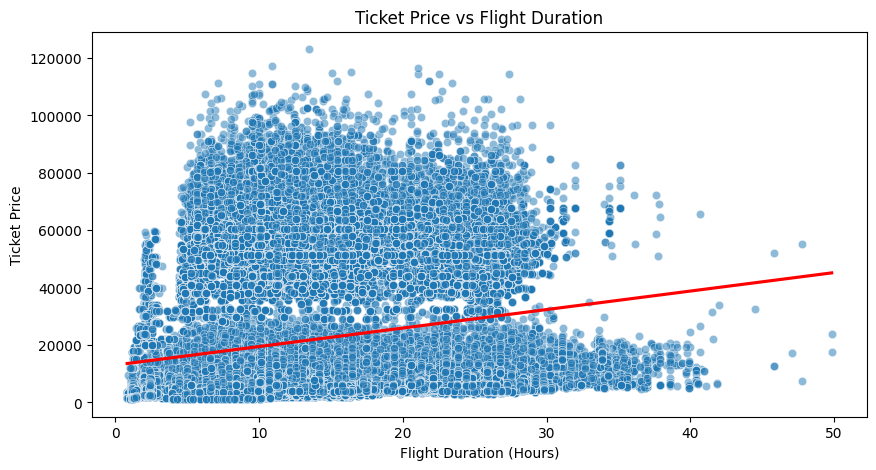

In [49]:
# How does ticket price vary with flight duration?
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='duration',
    y='price',
    alpha=0.5
)

sns.regplot(
    data=df,
    x='duration',
    y='price',
    scatter=False,
    color='red'
)

plt.title('Ticket Price vs Flight Duration')
plt.xlabel('Flight Duration (Hours)')
plt.ylabel('Ticket Price')

plt.show()

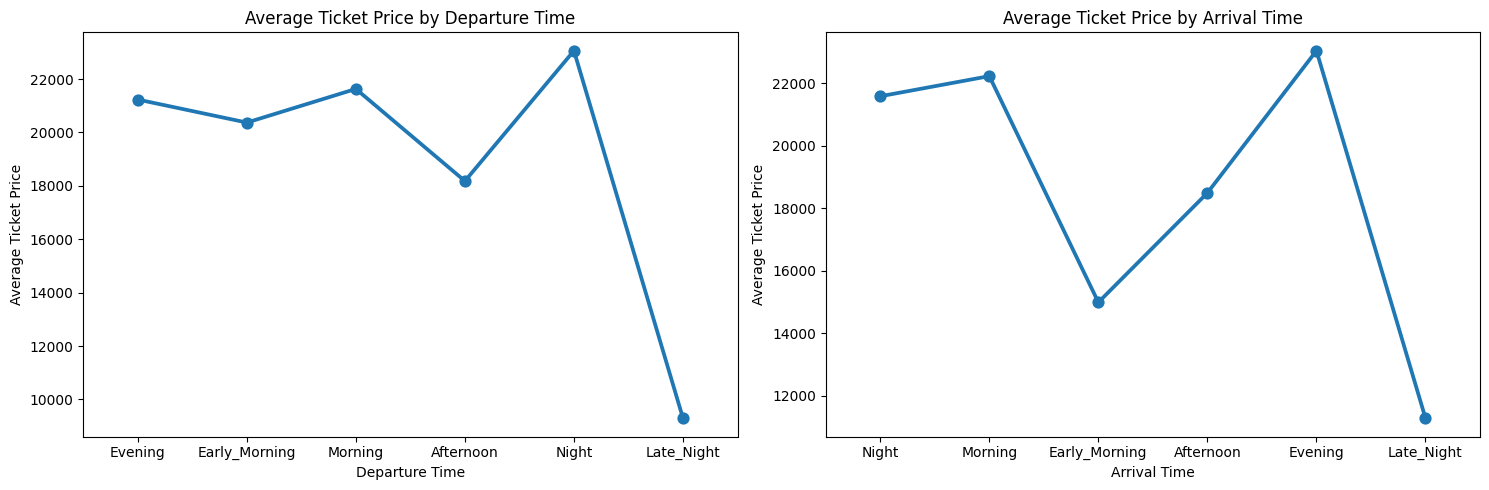

In [57]:
# How do ticket prices vary by departure and arrival time?
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

sns.pointplot(
    data=df,
    x='departure_time',
    y='price',
    errorbar=None
)

plt.title('Average Ticket Price by Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Average Ticket Price')

plt.subplot(1,2,2)

sns.pointplot(
    data=df,
    x='arrival_time',
    y='price',
    errorbar=None
)

plt.title('Average Ticket Price by Arrival Time')
plt.xlabel('Arrival Time')
plt.ylabel('Average Ticket Price')

plt.tight_layout()

plt.show()

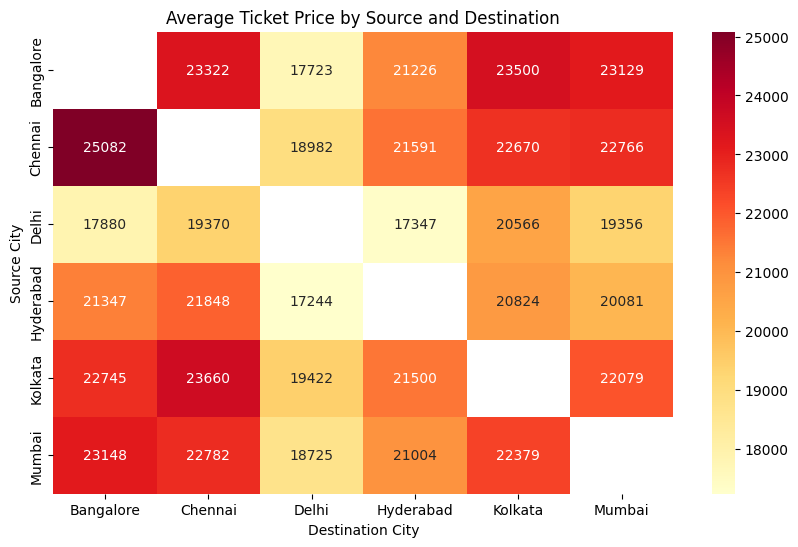

In [51]:
# Which source–destination routes have the highest average ticket prices?
route_price = df.pivot_table(
    values='price',
    index='source_city',
    columns='destination_city',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    route_price,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Average Ticket Price by Source and Destination')

plt.xlabel('Destination City')
plt.ylabel('Source City')

plt.show()

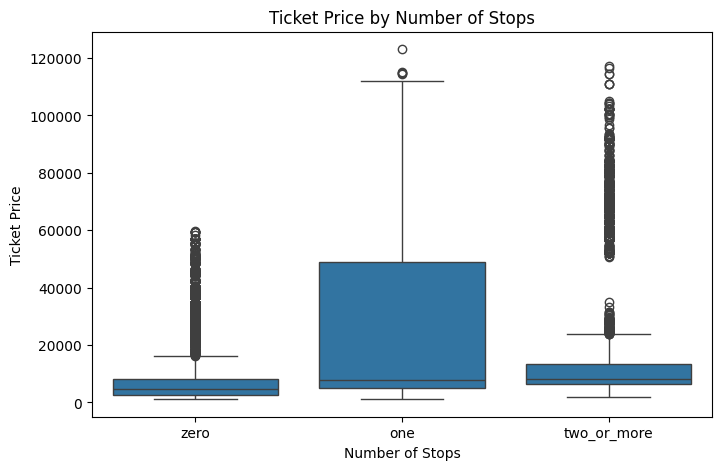

In [61]:
# How do ticket prices vary based on the number of stops?
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='stops',
    y='price'
)

plt.title('Ticket Price by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Ticket Price')

plt.show()

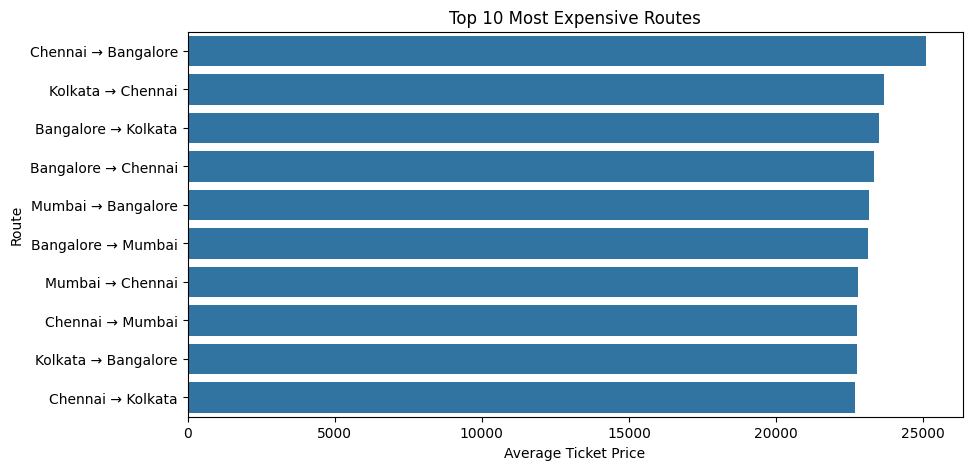

In [44]:
# Top 10 Most Expensive Routes
top_routes = (
    df.groupby(['source_city','destination_city'])['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_routes,
    x='price',
    y=top_routes['source_city'] + " → " + top_routes['destination_city']
)

plt.title('Top 10 Most Expensive Routes')
plt.xlabel('Average Ticket Price')
plt.ylabel('Route')

plt.show()

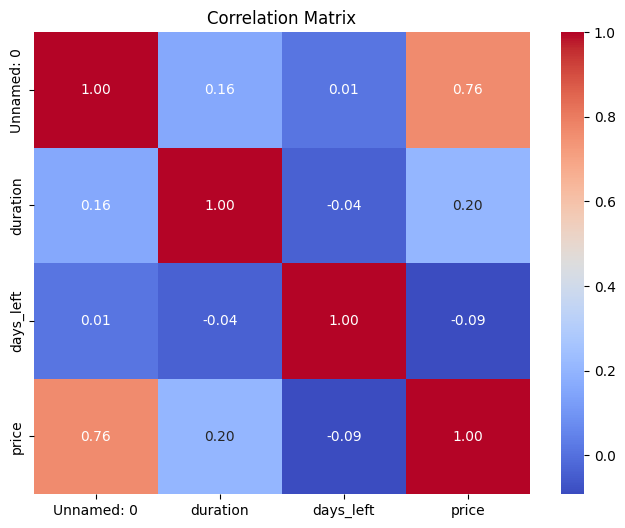

In [53]:
# Is there a correlation between ticket price and numerical flight attributes?
plt.figure(figsize=(8,6))

numeric_cols = df.select_dtypes(include='number')

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()